In [1]:
import pandas as pd
from CosinorPy import file_parser, cosinor, cosinor1
import numpy as np

In [2]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_5_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)
unusable_samples = [
    "A2450525897_n01_LICRNA01_A06",
    "A2450525897_n01_LICRNA01_A08",
    "A2450525897_n01_LICRNA01_C11",
    "A2450525897_n01_LICRNA01_D11",
    "A2450525897_n01_LICRNA01_D12",
    "A2449446903_n01_LICRNA02_F01",
    "B2449500127_n01_LICRNA04_A04",
    "B2449500127_n01_LICRNA04_A06",
    "B2449500127_n01_LICRNA04_A07",
]
borderline_unusable = [
    "A2450525897_n01_LICRNA01_F03",
    "A2450525897_n01_LICRNA01_G07",
    "A2449446903_n01_LICRNA02_A04",
    "A2449446903_n01_LICRNA02_H10",
    "B2449500127_n01_LICRNA04_H02",
    "B2449500127_n01_LICRNA04_H11",
]
all_unsable = borderline_unusable + unusable_samples
# trimmed_transcriptome = transcriptome.drop(index=all_unsable)
# trimmed_metadata = metadata.drop(index=all_unsable)
## Get plate 5 samples and remove what they replaced from the metadata to avoid duplicates
plate_5_replacements = metadata.loc[metadata["rnaprepplate"] == "LICRNA_05"]
non_plate_5_samples = metadata.loc[metadata["rnaprepplate"] != "LICRNA_05"]
replaced_samples = non_plate_5_samples.loc[
    non_plate_5_samples["sampID"].isin(plate_5_replacements["sampID"])
]
trimmed_metadata = metadata.drop(index=replaced_samples.index)
### get duplicates and drop the one with higher total genes, so that we can drop everything from the main list
double_duplicates = (
    trimmed_metadata.loc[
        trimmed_metadata.duplicated(
            subset="sampID",
            keep=False,
        )
    ]
    .sort_values(by="Total Reads")
    .drop_duplicates(subset="sampID", keep="first")
)
trimmed_metadata = trimmed_metadata.drop(index=double_duplicates.index)
trimmed_metadata
trimmed_transcriptome = transcriptome.loc[trimmed_metadata.index]
trimmed_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,4.944011,1.397952,0.0,5.994827,5.876072,0.0,0.0,58.062147,0.0,15.150509,...,0.000000,13.256631,0.000000,0.938539,0.0,0.0,0.956942,0.0,0.000000,1.597223
A2450525897_n01_LICRNA01_B01,2.911492,4.379655,0.0,2.665837,3.261267,0.0,0.0,57.934612,0.0,10.439273,...,0.000000,13.734068,0.000000,0.350043,0.0,0.0,0.166556,0.0,0.000000,2.184266
A2450525897_n01_LICRNA01_C01,6.270921,9.657724,0.0,0.000000,4.158376,0.0,0.0,38.161651,0.0,10.623477,...,34.304262,31.001035,0.000000,0.000000,0.0,0.0,0.051248,0.0,0.000000,0.855379
A2450525897_n01_LICRNA01_E01,3.690795,5.635420,0.0,3.786748,2.141076,0.0,0.0,37.996762,0.0,8.530523,...,0.000000,9.676399,0.000000,0.000000,0.0,0.0,0.142875,0.0,0.000000,1.987260
A2450525897_n01_LICRNA01_F01,2.781737,8.695001,0.0,2.016710,8.565957,0.0,0.0,64.854957,0.0,16.845214,...,0.000000,67.280011,0.000000,0.000000,0.0,0.0,0.496000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0.000000,8.339930,0.0,7.860235,3.199519,0.0,0.0,39.201659,0.0,1.057777,...,0.000000,4.602930,22.529946,1.333133,0.0,0.0,0.036247,0.0,4.867353,5.293749
A2534491401_n01_LICRNA05_E12,0.000000,1.692107,0.0,1.577446,3.055581,0.0,0.0,29.564231,0.0,12.872063,...,0.000000,6.899039,1.605254,3.951394,0.0,0.0,0.839348,0.0,0.000000,3.222183
A2534491401_n01_LICRNA05_F12,0.641335,5.972190,0.0,1.641699,5.632121,0.0,0.0,48.940407,0.0,24.612749,...,0.000000,7.502750,0.000000,1.799150,0.0,0.0,0.000000,0.0,0.000000,0.145801


In [4]:
circadian_metadata = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"].str.contains("Circadian Experiment 1")
]
circadian_transcriptome = trimmed_transcriptome.loc[
    trimmed_metadata["Experiment Type"].str.contains("Circadian Experiment 1")
]
circadian_metadata["Time Since Start"] = (
    circadian_metadata["Date and Time"]
    - circadian_metadata.sort_values(by="Date and Time")["Date and Time"].iloc[0]
) / pd.Timedelta(hours=1)


circadian_metadata_2 = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"].str.contains("Circadian Experiment 2")
]
circadian_transcriptome_2 = trimmed_transcriptome.loc[
    trimmed_metadata["Experiment Type"].str.contains("Circadian Experiment 2")
]
circadian_metadata_2["Time Since Start"] = (
    circadian_metadata_2["Date and Time"]
    - circadian_metadata_2.sort_values(by="Date and Time")["Date and Time"].iloc[0]
) / pd.Timedelta(hours=1)

# lines below for when we finish all circadian data, until then we only use weekend 1
##circadian_metadata = trimmed_metadata.loc[trimmed_metadata['Experiment Type'].str.contains('Circadian')]

##circadian_transcriptome = trimmed_transcriptome.loc[trimmed_metadata['Experiment Type'].str.contains('Circadian')]


# circadian_expt_2_start_time = circadian_metadata.loc[circadian_metadata['Experiment Type'] == 'Circadian Experiment 2']['Date and Time'].min()
# circadian_metadata['Time Since Start'] = (circadian_metadata['Date and Time'] - circadian_metadata['Date and Time'].iloc[0])/pd.Timedelta(hours=1)
# circadian_metadata['Time Since Start'].loc[circadian_metadata['Experiment Type'] == 'Circadian Experiment 2'] = (circadian_metadata.loc[circadian_metadata['Experiment Type'] == 'Circadian Experiment 2']['Date and Time'] - circadian_expt_2_start_time)/pd.Timedelta(hours=1)

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_5724/469193494.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  circadian_metadata["Time Since Start"] = (
/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_5724/469193494.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  circadian_metadata_2["Time Since Start"] = (


In [5]:
## Filter genes down to speed up fitting regression and not bother analyzing zeros.
trimmed_circadian_transcriptome = circadian_transcriptome.loc[
    :, (circadian_transcriptome > 1).sum() > 20
]
trimmed_circadian_transcriptome

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,Arthcp087,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
B250508004_n01_LICRNA03_B05,0.397484,3.914962,0.528310,3.953698,40.794727,1.797838,1.465764,13.426630,50.427659,751.295222,...,261.218299,20.331917,3.257055,60.688241,47.487560,7.765663,7.125035,0.000000,0.000000,0.271092
B250508004_n01_LICRNA03_C05,0.242429,4.428221,0.644440,3.014240,17.650893,1.824204,1.620340,10.899454,43.328510,707.648911,...,202.396203,0.000000,0.993252,108.967489,0.000000,4.262705,4.528588,5.683607,5.465007,1.240060
B250508004_n01_LICRNA03_D05,1.673381,6.023319,1.853456,2.654170,54.553650,0.495411,4.088131,10.668133,39.628764,546.454230,...,115.415643,7.003306,0.000000,108.815011,3.869407,3.923148,4.262576,0.000000,5.130271,3.423839
B250508004_n01_LICRNA03_E05,0.306973,2.902550,0.054401,2.195151,36.827954,0.060587,0.905597,12.384698,53.128935,552.554405,...,139.396819,5.138887,1.006157,23.824806,5.678587,1.439364,4.239898,0.000000,0.442881,2.763579
B250508004_n01_LICRNA03_F05,0.731436,8.981825,0.185176,3.511319,34.519120,0.360907,1.252293,14.317252,52.002506,646.797526,...,169.208243,2.915382,1.712433,19.709433,0.000000,2.449730,2.484234,0.000000,4.145698,0.213795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0.000000,8.339930,7.860235,3.199519,39.201659,1.057777,0.340746,10.691515,41.791184,735.130580,...,168.469799,9.281249,0.000000,40.986862,0.000000,0.000000,4.602930,22.529946,1.333133,5.293749
A2534491401_n01_LICRNA05_E12,0.000000,1.692107,1.577446,3.055581,29.564231,12.872063,1.199338,12.899944,63.214495,575.866112,...,201.254114,0.000000,8.976954,35.701763,69.663625,0.000000,6.899039,1.605254,3.951394,3.222183
A2534491401_n01_LICRNA05_F12,0.641335,5.972190,1.641699,5.632121,48.940407,24.612749,5.452616,11.798065,50.626712,722.137699,...,98.678964,0.000000,1.167825,38.226127,0.000000,0.000000,7.502750,0.000000,1.799150,0.145801


In [6]:
trimmed_circadian_transcriptome_2 = circadian_transcriptome_2.loc[
    :, (circadian_transcriptome_2 > 1).sum() > 20
]
trimmed_circadian_transcriptome_2

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,ArthCp081,Arthcp087,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCt124,ArthCr088,ArthCp088,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
B2449500127_n01_LICRNA04_C07,0.369734,5.032079,2.293318,1.259021,23.750115,0.243247,1.249811,12.782414,42.792364,518.390577,...,493.989825,130.697200,0.000000,0.000000,12.881989,0.000000,5.778798,0.279057,2.667137,3.025989
B2449500127_n01_LICRNA04_D07,0.000000,7.451890,2.867837,1.926605,23.558990,0.380231,0.000000,13.051683,36.361155,672.418492,...,552.948569,143.955638,0.000000,1.262882,20.367911,8.909376,0.000000,1.832069,5.280899,1.892027
B2449500127_n01_LICRNA04_E07,0.629969,6.656039,0.651243,2.907280,31.338727,2.745762,0.096795,14.386294,49.448987,636.251551,...,604.710033,160.370885,52.729929,3.441382,22.705770,50.984304,0.000000,2.615081,5.301787,0.644477
B2449500127_n01_LICRNA04_F07,0.402656,7.895757,2.854316,5.222927,37.193012,8.245217,0.000000,8.141649,38.178456,838.687245,...,455.668335,119.556438,5.617224,0.000000,34.770314,4.655370,11.800070,2.849112,5.809265,6.384911
B2449500127_n01_LICRNA04_G07,0.304598,4.418313,1.214553,5.117861,46.119998,2.630170,2.948491,11.013590,44.609410,709.073313,...,504.532264,137.004033,0.000000,12.479630,21.316629,56.346383,0.000000,4.827800,3.295902,0.623225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_G07,0.620785,7.781875,2.872592,3.449003,33.680234,0.000000,0.381535,14.439102,58.338653,612.626451,...,425.607903,169.207077,21.169395,4.521618,53.699446,0.000000,1.617107,8.589862,3.731784,7.197594
A2534491401_n01_LICRNA05_H07,0.000000,2.561732,2.535106,2.600397,37.505886,0.470562,0.627991,16.528305,50.760850,418.701771,...,617.991355,142.246134,26.608134,24.559935,114.289511,0.000000,0.000000,13.418790,3.931116,3.205647
A2534491401_n01_LICRNA05_A10,0.000000,0.000000,0.000000,0.000000,0.000000,0.293215,0.000000,0.000000,0.529054,2.343661,...,229.169651,0.187108,0.000000,19.477414,356.256463,13.740916,0.000000,25.564923,4.286696,64.440730


In [7]:
trimmed_circadian_transcriptome = trimmed_circadian_transcriptome.merge(
    right=circadian_metadata[["timepoint", "Time Since Start"]],
    left_index=True,
    right_index=True,
)
trimmed_circadian_transcriptome = trimmed_circadian_transcriptome.set_index(
    "timepoint", append=False
)
trimmed_circadian_transcriptome

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp085,Time Since Start
timepoint,,,,,,,,,,,,,,,,,,,,,
c1_t01,0.397484,3.914962,0.528310,3.953698,40.794727,1.797838,1.465764,13.426630,50.427659,751.295222,...,20.331917,3.257055,60.688241,47.487560,7.765663,7.125035,0.000000,0.000000,0.271092,0.0
c1_t01,0.242429,4.428221,0.644440,3.014240,17.650893,1.824204,1.620340,10.899454,43.328510,707.648911,...,0.000000,0.993252,108.967489,0.000000,4.262705,4.528588,5.683607,5.465007,1.240060,0.0
c1_t01,1.673381,6.023319,1.853456,2.654170,54.553650,0.495411,4.088131,10.668133,39.628764,546.454230,...,7.003306,0.000000,108.815011,3.869407,3.923148,4.262576,0.000000,5.130271,3.423839,0.0
c1_t01,0.306973,2.902550,0.054401,2.195151,36.827954,0.060587,0.905597,12.384698,53.128935,552.554405,...,5.138887,1.006157,23.824806,5.678587,1.439364,4.239898,0.000000,0.442881,2.763579,0.0
c1_t01,0.731436,8.981825,0.185176,3.511319,34.519120,0.360907,1.252293,14.317252,52.002506,646.797526,...,2.915382,1.712433,19.709433,0.000000,2.449730,2.484234,0.000000,4.145698,0.213795,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c1_t13,0.000000,8.339930,7.860235,3.199519,39.201659,1.057777,0.340746,10.691515,41.791184,735.130580,...,9.281249,0.000000,40.986862,0.000000,0.000000,4.602930,22.529946,1.333133,5.293749,48.0
c1_t09,0.000000,1.692107,1.577446,3.055581,29.564231,12.872063,1.199338,12.899944,63.214495,575.866112,...,0.000000,8.976954,35.701763,69.663625,0.000000,6.899039,1.605254,3.951394,3.222183,32.0
c1_t04,0.641335,5.972190,1.641699,5.632121,48.940407,24.612749,5.452616,11.798065,50.626712,722.137699,...,0.000000,1.167825,38.226127,0.000000,0.000000,7.502750,0.000000,1.799150,0.145801,12.0


In [8]:
trimmed_circadian_transcriptome_2 = trimmed_circadian_transcriptome_2.merge(
    right=circadian_metadata_2[["timepoint", "Time Since Start"]],
    left_index=True,
    right_index=True,
)
trimmed_circadian_transcriptome_2 = trimmed_circadian_transcriptome_2.set_index(
    "timepoint", append=False
)
trimmed_circadian_transcriptome_2

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,Arthcp087,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCt124,ArthCr088,ArthCp088,ArthCp085,Time Since Start
timepoint,,,,,,,,,,,,,,,,,,,,,
c2_t01,0.369734,5.032079,2.293318,1.259021,23.750115,0.243247,1.249811,12.782414,42.792364,518.390577,...,130.697200,0.000000,0.000000,12.881989,0.000000,5.778798,0.279057,2.667137,3.025989,0.0
c2_t01,0.000000,7.451890,2.867837,1.926605,23.558990,0.380231,0.000000,13.051683,36.361155,672.418492,...,143.955638,0.000000,1.262882,20.367911,8.909376,0.000000,1.832069,5.280899,1.892027,0.0
c2_t01,0.629969,6.656039,0.651243,2.907280,31.338727,2.745762,0.096795,14.386294,49.448987,636.251551,...,160.370885,52.729929,3.441382,22.705770,50.984304,0.000000,2.615081,5.301787,0.644477,0.0
c2_t01,0.402656,7.895757,2.854316,5.222927,37.193012,8.245217,0.000000,8.141649,38.178456,838.687245,...,119.556438,5.617224,0.000000,34.770314,4.655370,11.800070,2.849112,5.809265,6.384911,0.0
c2_t01,0.304598,4.418313,1.214553,5.117861,46.119998,2.630170,2.948491,11.013590,44.609410,709.073313,...,137.004033,0.000000,12.479630,21.316629,56.346383,0.000000,4.827800,3.295902,0.623225,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c2_t13,0.620785,7.781875,2.872592,3.449003,33.680234,0.000000,0.381535,14.439102,58.338653,612.626451,...,169.207077,21.169395,4.521618,53.699446,0.000000,1.617107,8.589862,3.731784,7.197594,48.0
c2_t13,0.000000,2.561732,2.535106,2.600397,37.505886,0.470562,0.627991,16.528305,50.760850,418.701771,...,142.246134,26.608134,24.559935,114.289511,0.000000,0.000000,13.418790,3.931116,3.205647,48.0
c2_t01,0.000000,0.000000,0.000000,0.000000,0.000000,0.293215,0.000000,0.000000,0.529054,2.343661,...,0.187108,0.000000,19.477414,356.256463,13.740916,0.000000,25.564923,4.286696,64.440730,0.0


In [13]:
cosinor_formatted_circadian_transcriptome = trimmed_circadian_transcriptome.melt(
    id_vars="Time Since Start", var_name="Gene", value_name="y"
)
cosinor_formatted_circadian_transcriptome = (
    cosinor_formatted_circadian_transcriptome.rename(
        columns={"Gene": "test", "Time Since Start": "x"}
    )
)
cosinor_formatted_circadian_transcriptome = cosinor_formatted_circadian_transcriptome[
    ["test", "x", "y"]
]
cosinor_formatted_circadian_transcriptome

,test,x,y
0,AT1G01010,0.0,0.397484
1,AT1G01010,0.0,0.242429
2,AT1G01010,0.0,1.673381
3,AT1G01010,0.0,0.306973
4,AT1G01010,0.0,0.731436
...,...,...,...
1792747,ArthCp085,48.0,5.293749
1792748,ArthCp085,32.0,3.222183
1792749,ArthCp085,12.0,0.145801
1792750,ArthCp085,32.0,3.821523


In [14]:
cosinor_formatted_circadian_transcriptome_2 = trimmed_circadian_transcriptome_2.melt(
    id_vars="Time Since Start", var_name="Gene", value_name="y"
)
cosinor_formatted_circadian_transcriptome_2 = (
    cosinor_formatted_circadian_transcriptome_2.rename(
        columns={"Gene": "test", "Time Since Start": "x"}
    )
)
cosinor_formatted_circadian_transcriptome_2 = (
    cosinor_formatted_circadian_transcriptome_2[["test", "x", "y"]]
)
cosinor_formatted_circadian_transcriptome_2

,test,x,y
0,AT1G01010,0.0,0.369734
1,AT1G01010,0.0,0.000000
2,AT1G01010,0.0,0.629969
3,AT1G01010,0.0,0.402656
4,AT1G01010,0.0,0.304598
...,...,...,...
1776627,ArthCp085,48.0,7.197594
1776628,ArthCp085,48.0,3.205647
1776629,ArthCp085,0.0,64.440730
1776630,ArthCp085,16.0,3.510440


In [15]:
cosinor_formatted_circadian_transcriptome.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Cosinor_gene_plotting_data.csv",
    index=False,
)

In [16]:
cosinor_gene_results = cosinor1.fit_group(
    cosinor_formatted_circadian_transcriptome, period=[24], plot_on=False
)

In [18]:
cosinor_gene_results_2 = cosinor1.fit_group(
    cosinor_formatted_circadian_transcriptome_2, period=[24], plot_on=False
)

In [19]:
cosinor_gene_results.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Gene_cosine_results_circadian_experiment_1_more_genes.csv",
    index=False,
)
cosinor_gene_results_2.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Gene_cosine_results_circadian_experiment_2_more_genes.csv",
    index=False,
)

In [26]:
cosinor_gene_results_2 = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Gene_cosine_results_circadian_experiment_2.csv"
)

In [27]:
cosinor_gene_results = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Gene_cosine_results_circadian_experiment_1.csv"
)

In [ ]:
def plot_single_gene_cosinor(gene_name):
    single_gene_data = cosinor_formatted_circadian_transcriptome.loc[
        cosinor_formatted_circadian_transcriptome["test"] == gene_name
    ]
    results = cosinor1.fit_group(single_gene_data, period=[24], plot_on=True)
    print(results)

In [1]:
cosinor_gene_results.sort_values(by="q").head(20)

NameError: name 'cosinor_gene_results' is not defined

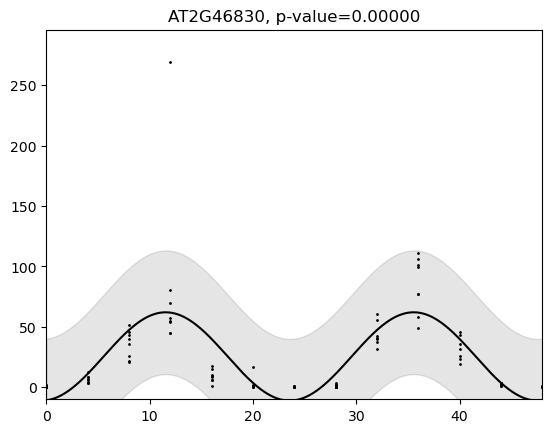

        test  period             p             q  amplitude  p(amplitude)  \
0  AT2G46830    24.0  2.225084e-17  2.225084e-17  36.555938  3.267348e-26   

   q(amplitude)                            CI(amplitude)  acrophase  \
0  3.267348e-26  [29.791162334579816, 43.32071462144045]  -3.022966   

    p(acrophase)   q(acrophase)                            CI(acrophase)  \
0  9.995344e-218  9.995344e-218  [-3.21108433154816, -2.834846804575057]   

   acrophase[h]  
0     11.546878  


In [ ]:
plot_single_gene_cosinor("AT2G46830")

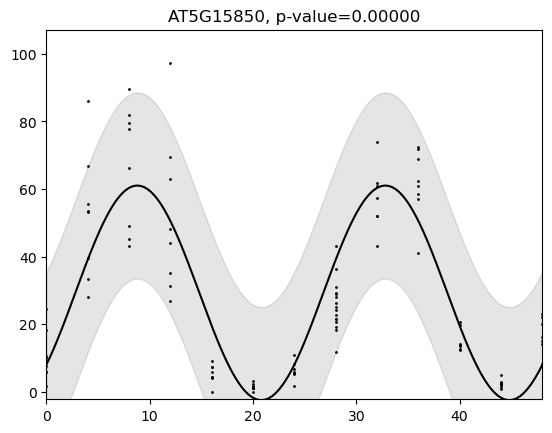

        test  period             p             q  amplitude  p(amplitude)  \
0  AT5G15850    24.0  4.821548e-30  4.821548e-30  31.724396  2.952672e-61   

   q(amplitude)                             CI(amplitude)  acrophase  \
0  2.952672e-61  [27.958983663884034, 35.489809119243446]  -2.305139   

   p(acrophase)  q(acrophase)                               CI(acrophase)  \
0           0.0           0.0  [-2.4176885857544996, -2.1925894293528647]   

   acrophase[h]  
0      8.804982  


In [ ]:
plot_single_gene_cosinor("AT5G15850")

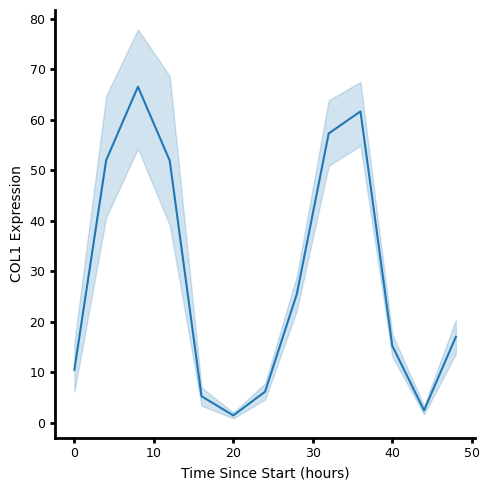

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

at5g15850_plot_data = pd.DataFrame(
    {
        "Time Since Start": circadian_metadata["Time Since Start"],
        "AT5G15850": circadian_transcriptome["AT5G15850"],
    }
).sort_values("Time Since Start")

fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
fig.patch.set_facecolor("white")
sns.lineplot(
    data=at5g15850_plot_data,
    x="Time Since Start",
    y="AT5G15850",
    errorbar=("ci", 95),
    color="#1f77b4",
    ax=ax,
    sort=True,
    estimator="mean",
)
plt.ylabel("COL1 Expression", fontsize=10)
plt.xlabel("Time Since Start (hours)", fontsize=10)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.spines["top"].set_color("black")
ax.spines["top"].set_linewidth(0)
ax.tick_params(axis="both", width=2)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

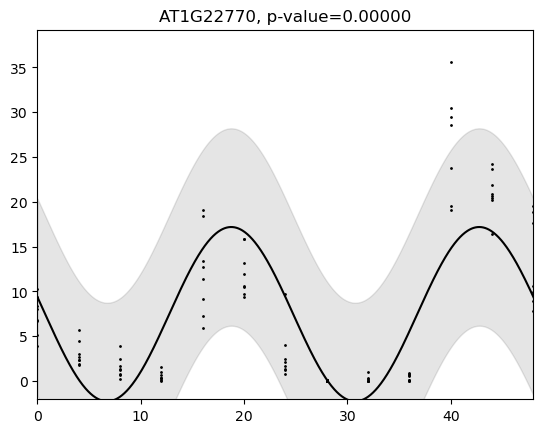

        test  period             p             q  amplitude  p(amplitude)  \
0  AT1G22770    24.0  4.944213e-22  4.944213e-22   9.720626  5.928245e-37   

   q(amplitude)                            CI(amplitude)  acrophase  \
0  5.928245e-37  [8.220438570590453, 11.220813319723316]   1.374443   

   p(acrophase)  q(acrophase)                            CI(acrophase)  \
0  1.189190e-74  1.189190e-74  [1.227078024883195, 1.5218070968167472]   

   acrophase[h]  
0     18.750016  


In [ ]:
plot_single_gene_cosinor("AT1G22770")

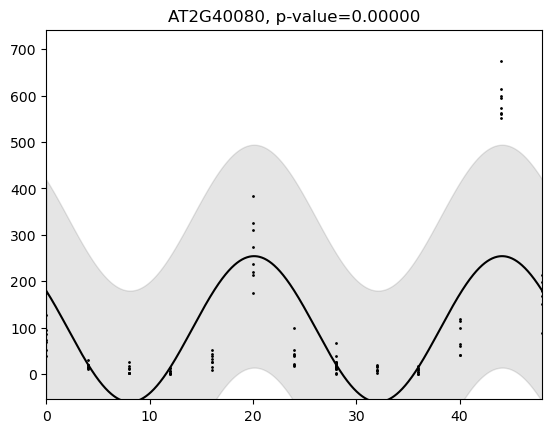

        test  period             p             q   amplitude  p(amplitude)  \
0  AT2G40080    24.0  1.378951e-14  1.378951e-14  157.197047  8.164542e-21   

   q(amplitude)                             CI(amplitude)  acrophase  \
0  8.164542e-21  [124.27152843557053, 190.12256622222276]   1.020565   

   p(acrophase)  q(acrophase)                            CI(acrophase)  \
0  4.422058e-24  4.422058e-24  [0.822944656388028, 1.2181846055415555]   

   acrophase[h]  
0      20.10173  


In [ ]:
plot_single_gene_cosinor("AT2G40080")

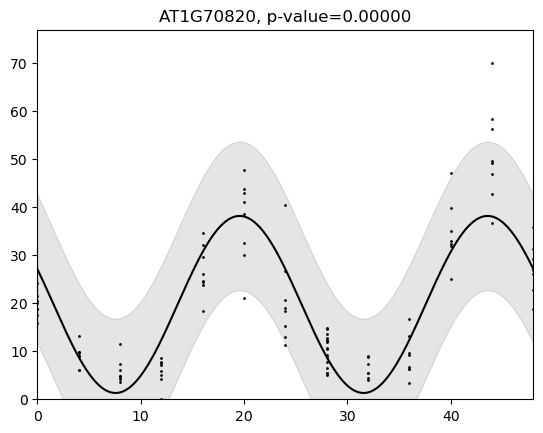

        test  period             p             q  amplitude  p(amplitude)  \
0  AT1G70820    24.0  4.245819e-31  4.245819e-31  18.437067  3.757758e-65   

   q(amplitude)                             CI(amplitude)  acrophase  \
0  3.757758e-65  [16.317127799668025, 20.557005618267258]     1.1623   

   p(acrophase)  q(acrophase)                            CI(acrophase)  \
0  1.282189e-97  1.282189e-97  [1.0536560582189847, 1.270944616013124]   

   acrophase[h]  
0      19.56034  


In [ ]:
plot_single_gene_cosinor("AT1G70820")

In [68]:
cosinor_results

,test,period,p,q,amplitude,p(amplitude),q(amplitude),CI(amplitude),acrophase,p(acrophase),q(acrophase),CI(acrophase),acrophase[h]
0,Actinomycetospora,24.0,5.379308e-12,2.766501e-11,0.383651,3.047744e-16,1.567411e-15,"[0.291630396333432, 0.47567254311538676]",-1.081838,6.856343e-18,2.468284e-17,"[-1.327897921329411, -0.8357787741086257]",4.132318
1,Actinoplanes,24.0,1.515468e-05,2.368931e-05,0.600663,6.900296e-07,1.080046e-06,"[0.36350704159520214, 0.8378191821456924]",-0.942379,6.815204e-06,9.813894e-06,"[-1.3528863034304124, -0.5318714846963519]",3.599622
2,Aetherobacter,24.0,5.978572e-09,1.956624e-08,0.345548,1.616941e-11,5.291806e-11,"[0.24501946864477123, 0.4460770634737622]",-1.109849,2.667294e-13,6.001412e-13,"[-1.4074145149139605, -0.8122838529378874]",4.239312
3,Agrobacterium,24.0,1.128190e-12,1.015371e-11,0.871859,2.181700e-17,1.963530e-16,"[0.6704358865537218, 1.073282661327319]",-0.984750,7.278634e-16,2.015622e-15,"[-1.2240430416224108, -0.7454577225670973]",3.761469
4,Aureimonas_A_501549,24.0,7.760615e-06,1.269919e-05,0.195302,2.911548e-07,4.764351e-07,"[0.12067146970843007, 0.2699316454512998]",-1.715619,4.324284e-20,2.594571e-19,"[-2.0819228279376887, -1.3493143714203895]",6.553180
5,Blastococcus,24.0,9.247049e-13,1.015371e-11,0.399117,1.590179e-17,1.908215e-16,"[0.3073072149039414, 0.4909267356202305]",-1.086556,1.733470e-19,7.803712e-19,"[-1.3224212990092707, -0.850691131094987]",4.150339
6,Brevundimonas,24.0,3.659592e-07,7.749723e-07,0.330625,4.997165e-09,1.058223e-08,"[0.2198016341469156, 0.44144802465301924]",-1.943269,3.057935e-33,2.752142e-32,"[-2.260336104381141, -1.6262023927273979]",7.422742
7,Caldora,24.0,1.174420e-11,5.284891e-11,0.310880,1.029738e-15,4.633819e-15,"[0.23493692534154612, 0.386823883046449]",-0.781499,2.514597e-09,4.114796e-09,"[-1.0384761442245374, -0.5245227742938336]",2.985108
8,Chryseobacterium_A_796612,24.0,6.802529e-03,7.420940e-03,0.336398,1.234972e-03,1.347242e-03,"[0.13231437725941173, 0.5404809990485882]",0.488410,1.055308e-01,1.117385e-01,"[-0.10300168951299726, 1.0798207898939212]",22.134413
9,Flavobacterium,24.0,2.125387e-03,2.391060e-03,3.225167,3.098560e-04,3.485880e-04,"[1.4726425179598766, 4.9776911621599345]",-1.167598,3.418771e-05,4.558362e-05,"[-1.719882393676773, -0.6153144360048817]",4.459897


In [ ]:
test_dataframe_cosinor = file_parser.generate_test_data(
    phase=0, n_components=1, name="test1", noise=0.5, replicates=3
)

In [13]:
test_dataframe_cosinor

,test,x,y
0,test1,0.0,0.469087
1,test1,2.0,1.011777
2,test1,4.0,0.954354
3,test1,6.0,0.061619
4,test1,8.0,0.287558
...,...,...,...
20,test1,40.0,-1.937984
21,test1,42.0,0.588971
22,test1,44.0,0.673770
23,test1,46.0,1.540919


In [23]:
gene_list = [
    "AT1G02920",
    "AT1G02930",
    "AT1G21110",
    "AT1G21120",
    "AT1G26380",
    "AT1G26410",
    "AT1G26420",
    "AT1G35230",
    "AT1G64170",
    "AT1G65500",
    "AT1G76930",
    "AT2G19190",
    "AT2G25470",
    "AT2G30750",
    "AT2G39200",
    "AT2G43620",
    "AT3G46280",
    "AT4G12490",
    "AT4G12500",
    "AT4G23140",
    "AT4G23220",
    "AT4G28420",
    "AT5G24110",
    "AT5G64120",
]

In [15]:
# Filter to genes in gene_list
filtered_circadian = cosinor_formatted_circadian_transcriptome[
    cosinor_formatted_circadian_transcriptome["test"].isin(gene_list)
].copy()

# Min-max normalize per gene
filtered_circadian["y"] = filtered_circadian.groupby("test")["y"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

filtered_circadian

,test,x,y
13189,AT1G02920,28.0,0.494270
13190,AT1G02920,32.0,0.464841
13191,AT1G02920,36.0,0.102176
13192,AT1G02920,44.0,0.089629
13193,AT1G02920,28.0,0.036142
...,...,...,...
1573846,AT5G64120,12.0,0.112786
1573847,AT5G64120,16.0,0.270429
1573848,AT5G64120,20.0,0.000000
1573849,AT5G64120,24.0,0.102916


In [24]:
# Filter to genes in gene_list
filtered_circadian_2 = cosinor_formatted_circadian_transcriptome_2[
    cosinor_formatted_circadian_transcriptome_2["test"].isin(gene_list)
].copy()

# Min-max normalize per gene
filtered_circadian_2["y"] = filtered_circadian_2.groupby("test")["y"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

filtered_circadian_2

,test,x,y
11648,AT1G02920,0.0,0.033225
11649,AT1G02920,0.0,0.166822
11650,AT1G02920,0.0,0.017154
11651,AT1G02920,0.0,0.024670
11652,AT1G02920,0.0,0.011197
...,...,...,...
1460259,AT5G64120,48.0,0.220638
1460260,AT5G64120,48.0,0.032711
1460261,AT5G64120,0.0,0.004603
1460262,AT5G64120,16.0,0.584692


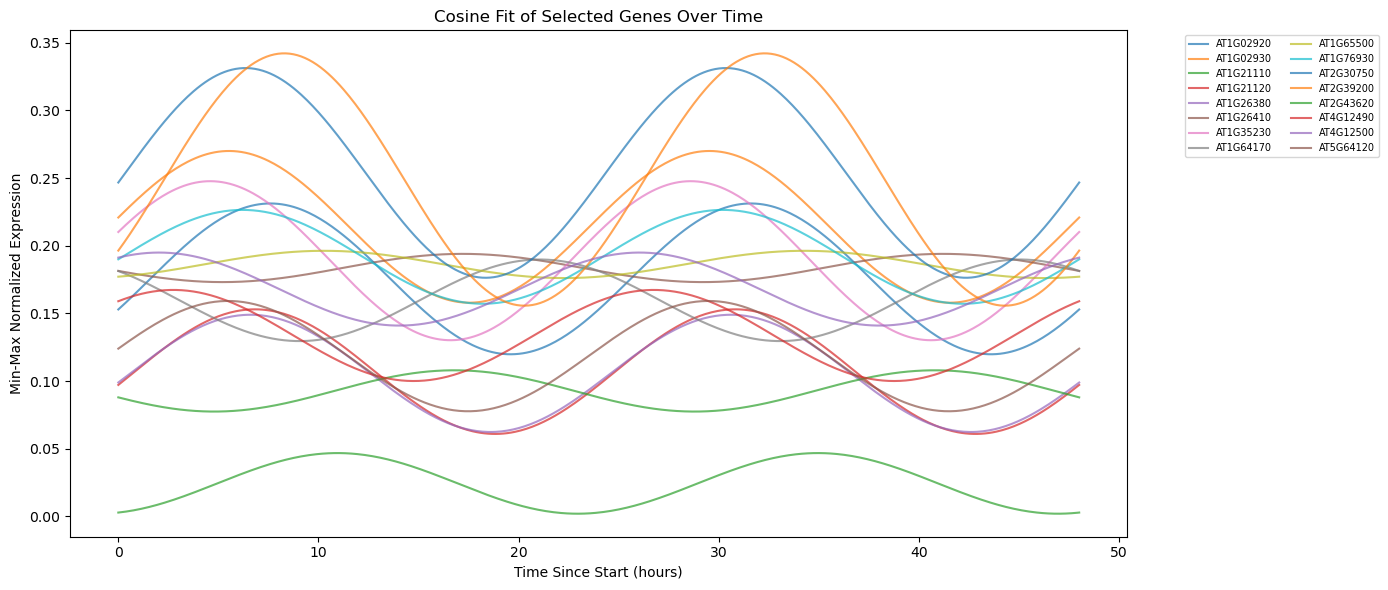

In [17]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def cosine_model(x, amplitude, phase, offset):
    return amplitude * np.cos(2 * np.pi * x / 24 - phase) + offset


fig, ax = plt.subplots(figsize=(14, 6))
x_fit = np.linspace(filtered_circadian["x"].min(), filtered_circadian["x"].max(), 500)

for gene, group in filtered_circadian.groupby("test"):
    x_data = group["x"].values
    y_data = group["y"].values
    try:
        popt, _ = curve_fit(
            cosine_model, x_data, y_data, p0=[0.5, 0, 0.5], maxfev=10000
        )
        ax.plot(x_fit, cosine_model(x_fit, *popt), label=gene, alpha=0.7)
    except RuntimeError:
        pass  # skip genes where fit doesn't converge

ax.set_xlabel("Time Since Start (hours)")
ax.set_ylabel("Min-Max Normalized Expression")
ax.set_title("Cosine Fit of Selected Genes Over Time")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

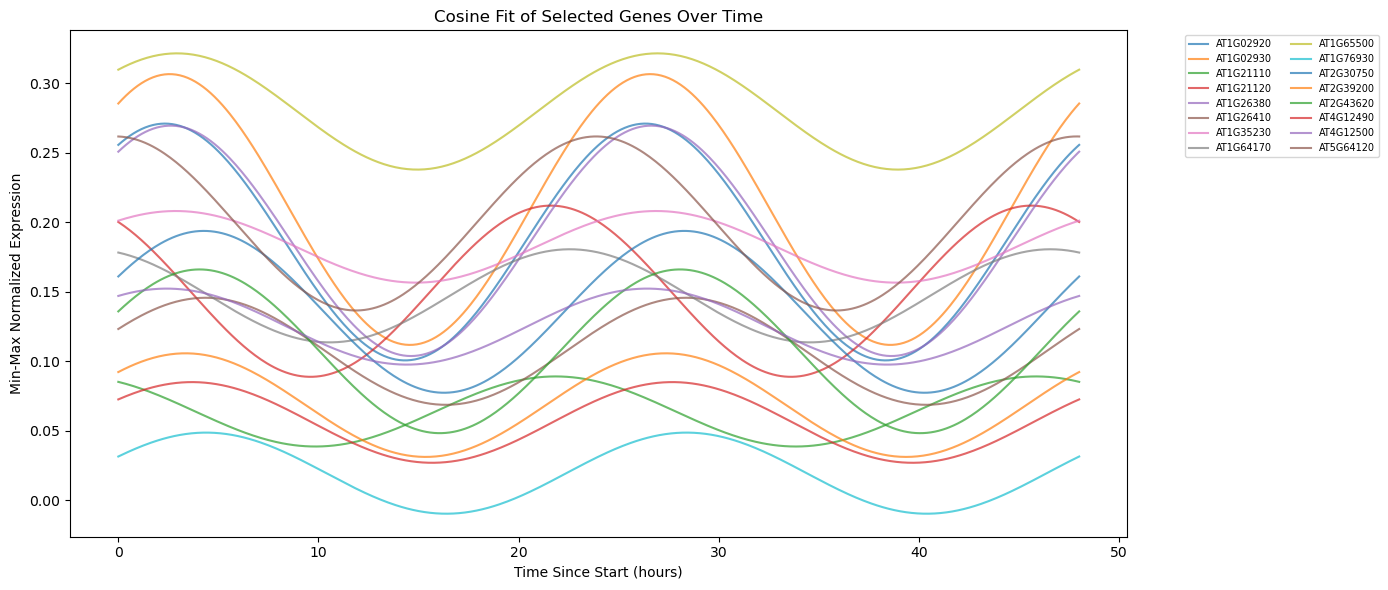

In [28]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def cosine_model(x, amplitude, phase, offset):
    return amplitude * np.cos(2 * np.pi * x / 24 - phase) + offset


fig, ax = plt.subplots(figsize=(14, 6))
x_fit = np.linspace(
    filtered_circadian_2["x"].min(), filtered_circadian_2["x"].max(), 500
)

for gene, group in filtered_circadian_2.groupby("test"):
    x_data = group["x"].values
    y_data = group["y"].values
    try:
        popt, _ = curve_fit(
            cosine_model, x_data, y_data, p0=[0.5, 0, 0.5], maxfev=10000
        )
        ax.plot(x_fit, cosine_model(x_fit, *popt), label=gene, alpha=0.7)
    except RuntimeError:
        pass  # skip genes where fit doesn't converge

ax.set_xlabel("Time Since Start (hours)")
ax.set_ylabel("Min-Max Normalized Expression")
ax.set_title("Cosine Fit of Selected Genes Over Time")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7, ncol=2)
plt.tight_layout()
plt.show()